# Gene level evaluation

In [1]:
import pandas as pd
from pathlib import Path
import os

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pi

## 0. Load paths

In [2]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"
CFG_DUAL = os.path.join(BASE_DIR_PROJECT, "configs/config.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [3]:
import random
import numpy as np
import torch

def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_full_reproducibility(42)

In [4]:
cfg = load_config(CFG_DUAL)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_CosmXPancreas'}), 'model': CfgNode({'n_embed': 128, 'local_component': CfgNode({'name': 'GCN', 'parameters': CfgNode({'hidden_dim': 512, 'num_layers': 1, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'parameters': CfgNode({'n_heads': 2, 'dim_feedforward': 256, 'dropout_global': 0.0, 'activation_func': 'relu', 'num_layers': 4, 'max_seq_len': 3000, 'long_range_attention': False, 'type_gex_embedding': None}), 'latent_obsm_key': None}), 'save': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/melton25/', 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'auto', 'lr': 0.005, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 40, 'lr_max_epochs': 100, 'wd': 0.01, 'loss': 'SCELoss', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'ea

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [6]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 0


In [7]:
model_name = "melton25/model"

In [8]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "melton25"), 
    adata, 
    cfg,
    model_name="model",
    local_component = True, 
    global_component = True, 
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/melton25/modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [9]:
print(dual_combined_model)

## 2. Gene level evaluation

In [10]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .X


In [11]:
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', '

### Gene loadings analysis

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

In [12]:
from InterScale.evaluation import gene_loadings

In [13]:
result.obs['slide'].cat.categories

Index(['Run5211_S1', 'Run5211_S2', 'Run5211_S3'], dtype='object')

In [14]:
result_s1 = result[result.obs['slide'] == 'Run5211_S1'].copy()
result_s2 = result[result.obs['slide'] == 'Run5211_S2'].copy()
result_s3 = result[result.obs['slide'] == 'Run5211_S3'].copy()

In [15]:
result_s1.layers["log1p_norm"] = result_s1.X
result_s2.layers["log1p_norm"] = result_s2.X
result_s3.layers["log1p_norm"] = result_s3.X

In [16]:
for adata in [result_s1, result_s2, result_s3]:
    gene_loadings(
        adata,
        dual_combined_model,
        local_latent_key = "_global_emb",
        global_latent_key = "_global_emb",
        layer_key="log1p_norm",
    )

In [15]:
# Select single slide for evaluation
ctrl_test = result[result.obs['sample'] == 'slide4_B2-2']
ctrl_test.obs

,Cell,Area,x,y,sample,condition,organoid,obs_names,split,_scvi_sample_key_0,_scvi_group_label,_cls_horizontal,_cls_vertical
39721,W5A2_c1,12758.0,2049.352,1118.874,slide4_B2-2,SHH,organoid #3,W5A2_c1,test,15,1,7.090614e-06,0.000009
39722,W5A2_c2,19453.0,2275.323,1170.405,slide4_B2-2,SHH,organoid #3,W5A2_c2,test,15,1,6.794825e-06,0.000009
39723,W5A2_c3,9538.0,1181.378,1158.448,slide4_B2-2,SHH,organoid #3,W5A2_c3,test,15,1,8.962671e-07,0.000019
39724,W5A2_c4,7787.0,2174.867,1198.309,slide4_B2-2,SHH,organoid #3,W5A2_c4,test,15,1,6.567258e-06,0.000002
39725,W5A2_c5,24243.0,2441.575,1175.163,slide4_B2-2,SHH,organoid #3,W5A2_c5,test,15,1,6.704096e-06,0.000007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41488,W5A2_c1774,12233.0,5082.481,7911.868,slide4_B2-2,SHH,organoid #3,W5A2_c1774,test,15,1,6.913979e-06,0.000007
41489,W5A2_c1775,11942.0,4843.871,7984.865,slide4_B2-2,SHH,organoid #3,W5A2_c1775,test,15,1,6.577774e-06,0.000014
41490,W5A2_c1776,8348.0,4585.569,7983.518,slide4_B2-2,SHH,organoid #3,W5A2_c1776,test,15,1,9.712367e-06,0.000005
41491,W5A2_c1777,10284.0,4479.319,8021.775,slide4_B2-2,SHH,organoid #3,W5A2_c1777,test,15,1,1.141503e-05,0.000012


In [16]:
# Define multiple gene sets
gene_sets = {
    "ventral": ['NKX6.1', 'NKX2.2', 'FOXA1','FOXA2'], #short
    "dorsal": ['DBX1','DBX2', 'IRX3', 'PAX6'] #long
}

In [19]:
from InterScale.evaluation import gene_set_covariance

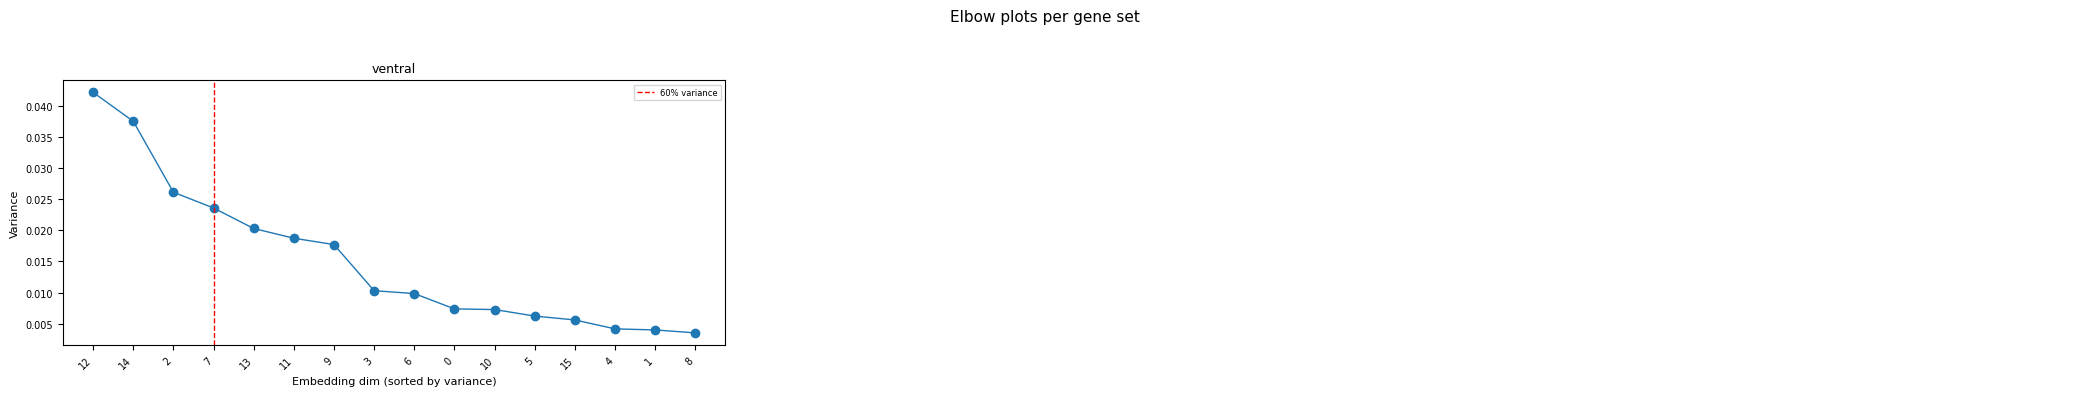

In [20]:
local_cov_df = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_local_std_gene_loadings', plot = ["ventral"])

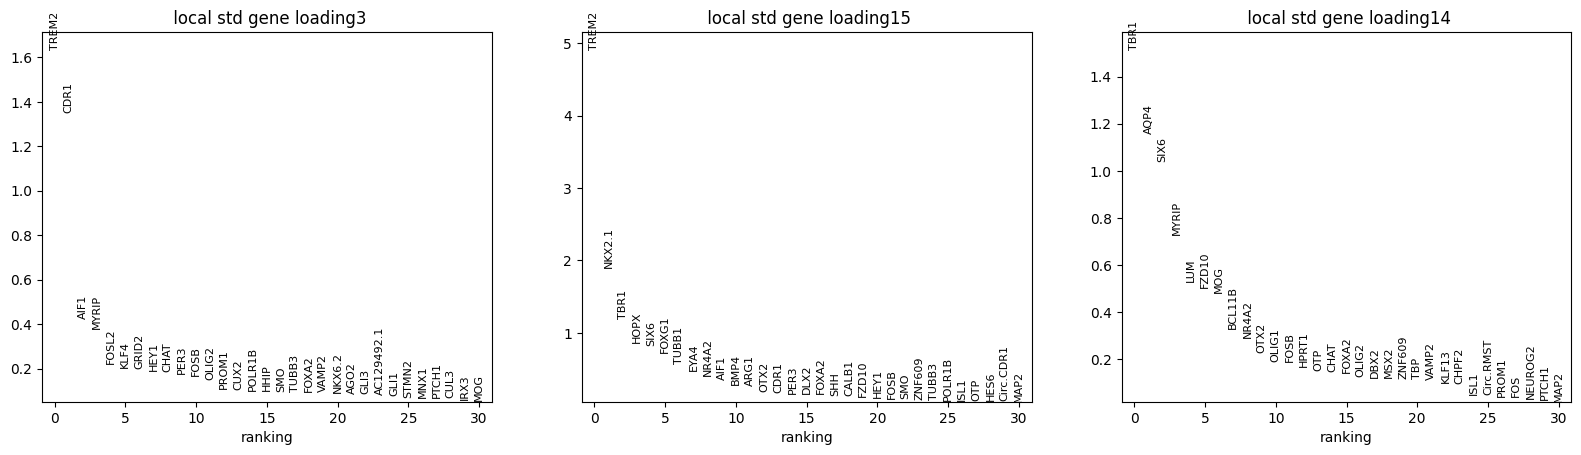

In [22]:
sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_local_std_gene_loadings',
    indices=[2,14,13],
)

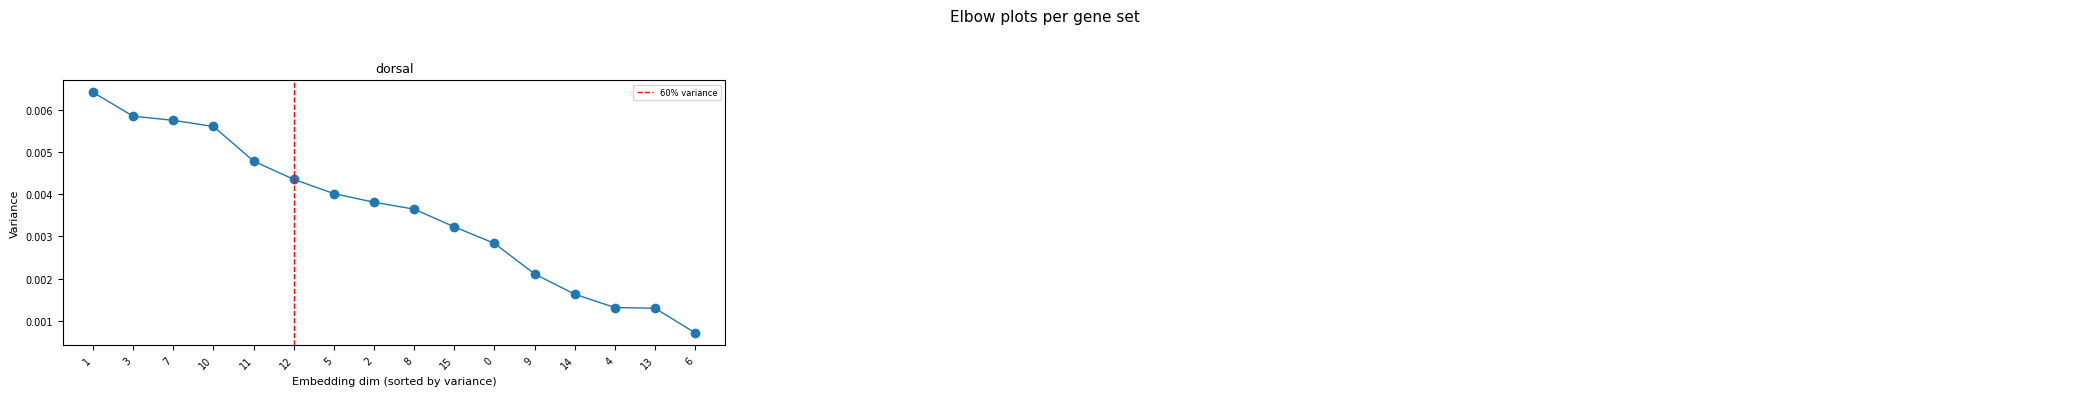

In [21]:
global_cov_df = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_global_std_gene_loadings', plot = ["dorsal"])

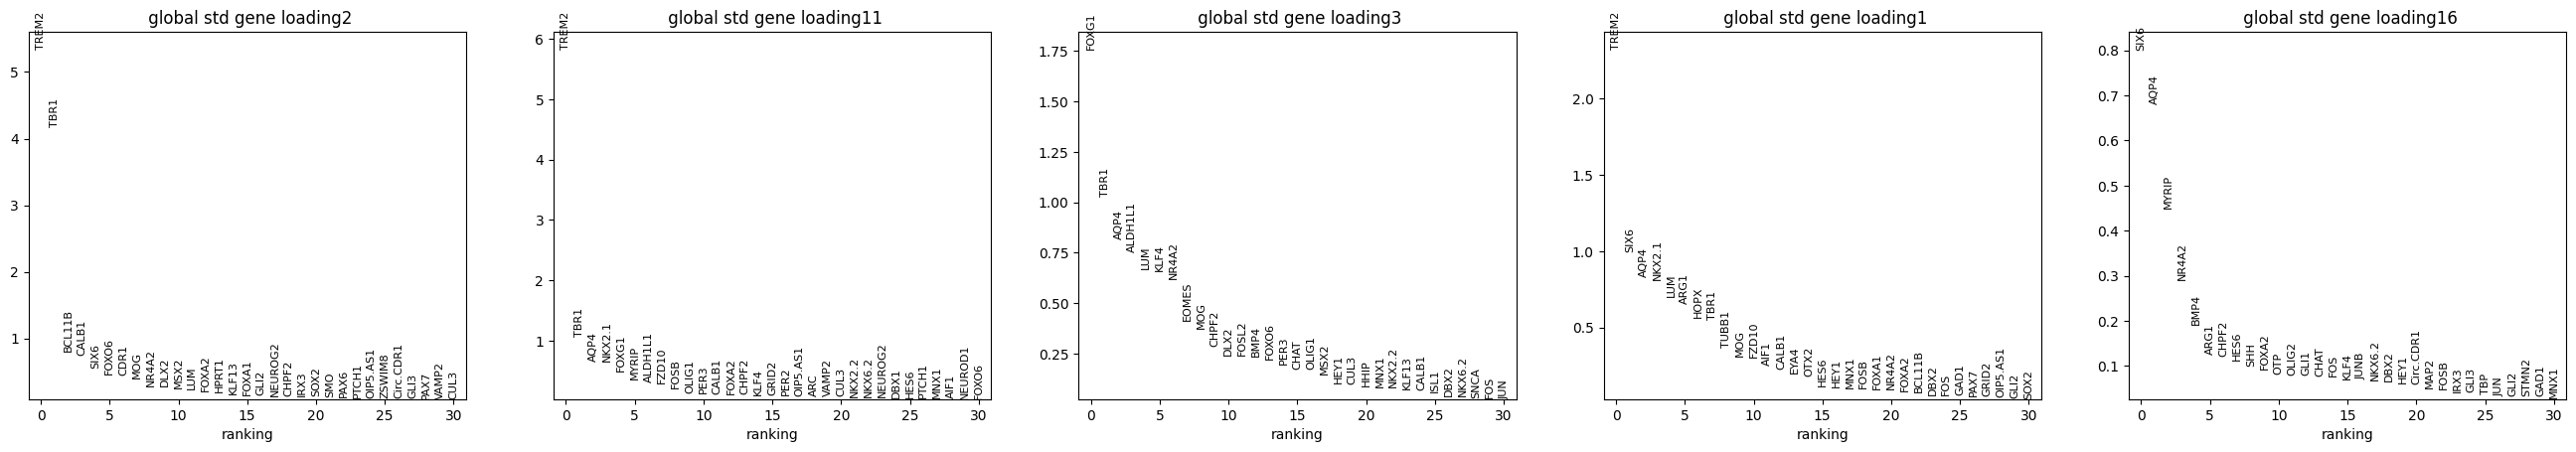

In [22]:
sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_global_std_gene_loadings',
    indices=[1,10,2,0,15],
)

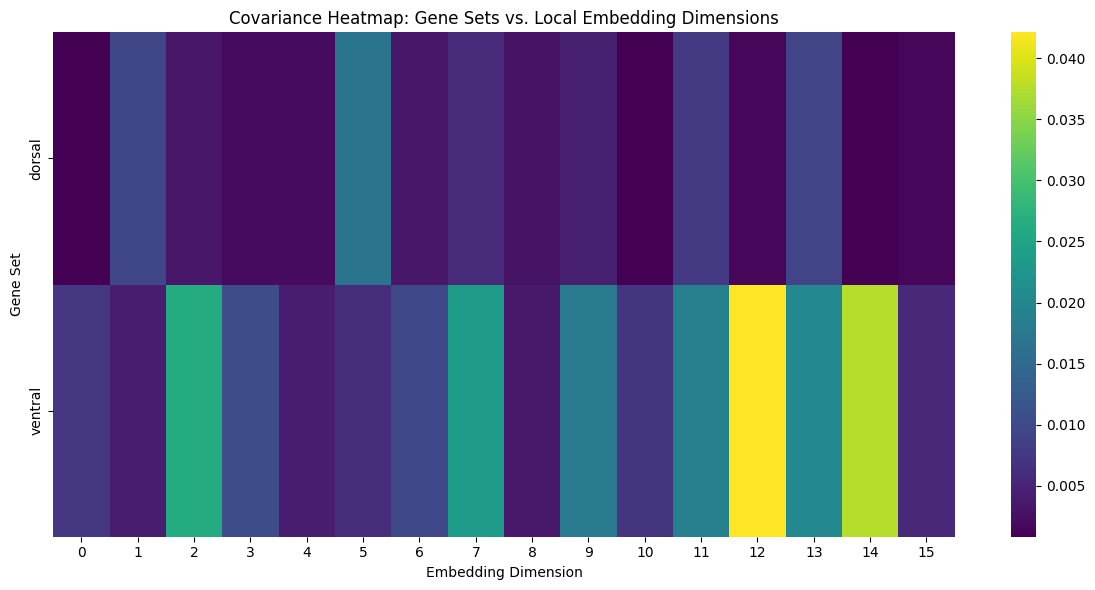

In [23]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = local_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

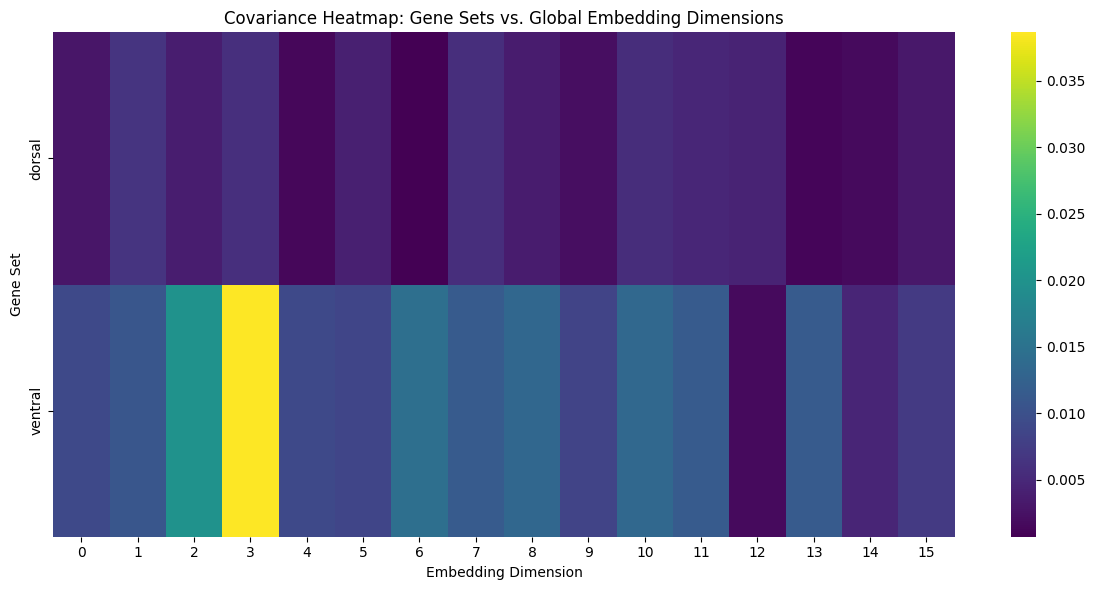

In [24]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = global_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [25]:
from InterScale.evaluation import spatial_covariance_plot

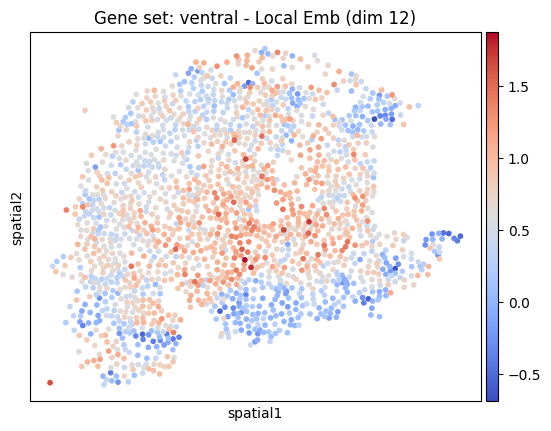

{'ventral': 12}

In [78]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "local",   # "local" or "global", 
    restrict_to = "ventral",
    emb_dim = 12, 
    cmap = "coolwarm"
)

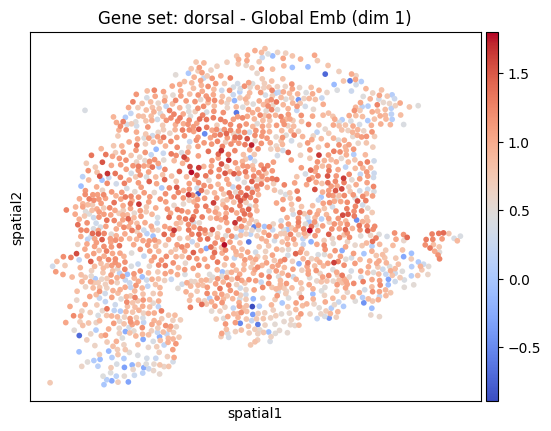

{'dorsal': 1}

In [79]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "global",   # "local" or "global", 
    restrict_to = "dorsal",
    emb_dim = 1, 
    cmap = "coolwarm"
)

#### Covariance analysis of embedding dimensions based on gene loadings

##### 1. Are the embedding dimensions linearly independent?

For the local and global embeddings separately: 

- Linear independence of embedding dimensions = columns of Z are linearly independent, i.e. rank(Z) == n_dims
- Visual: Plot the correlation between each embedding dimension. If the matrix is almost diagonal, we can assume linea independence. 

In [17]:
from InterScale.evaluation import latent_rank_report, pl_latent_correlation

In [19]:
# Check rank:
rep_global = latent_rank_report(result_s1, "_global_emb")
rep_local  = latent_rank_report(result_s1, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 108711, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 108711, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


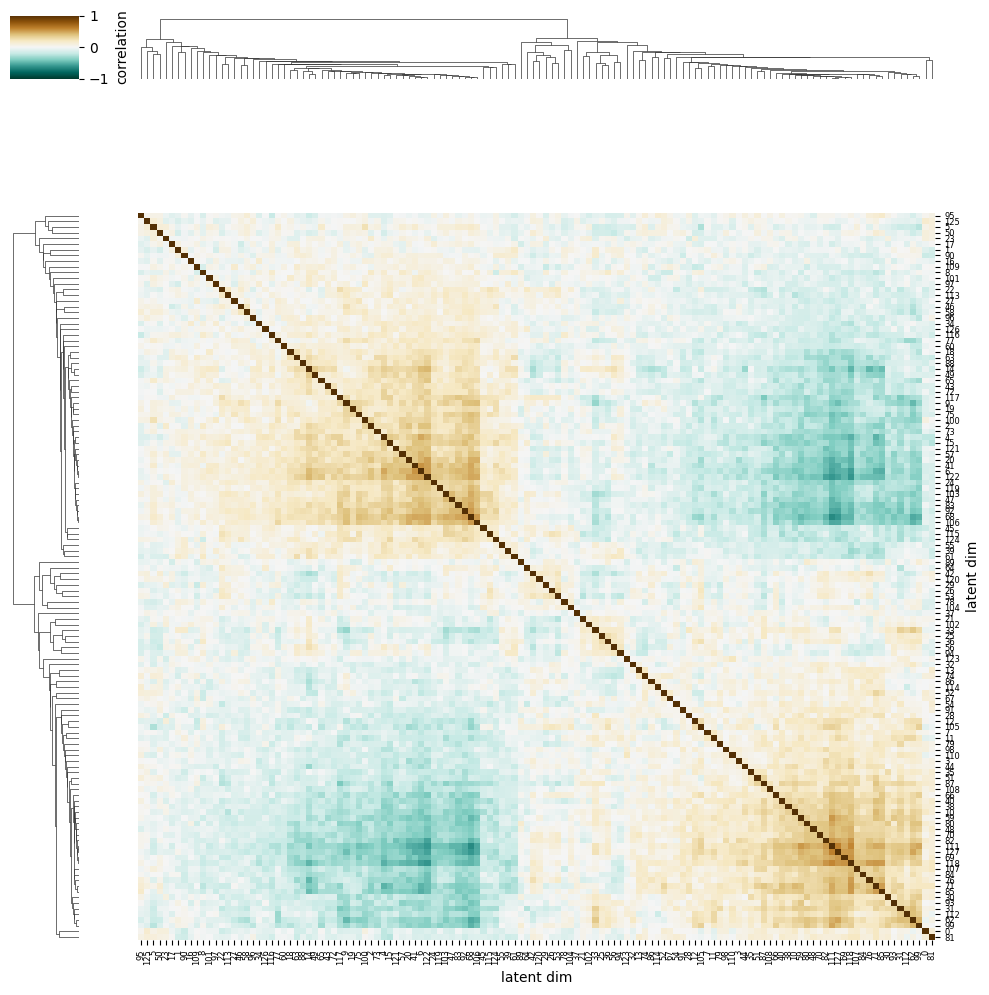

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


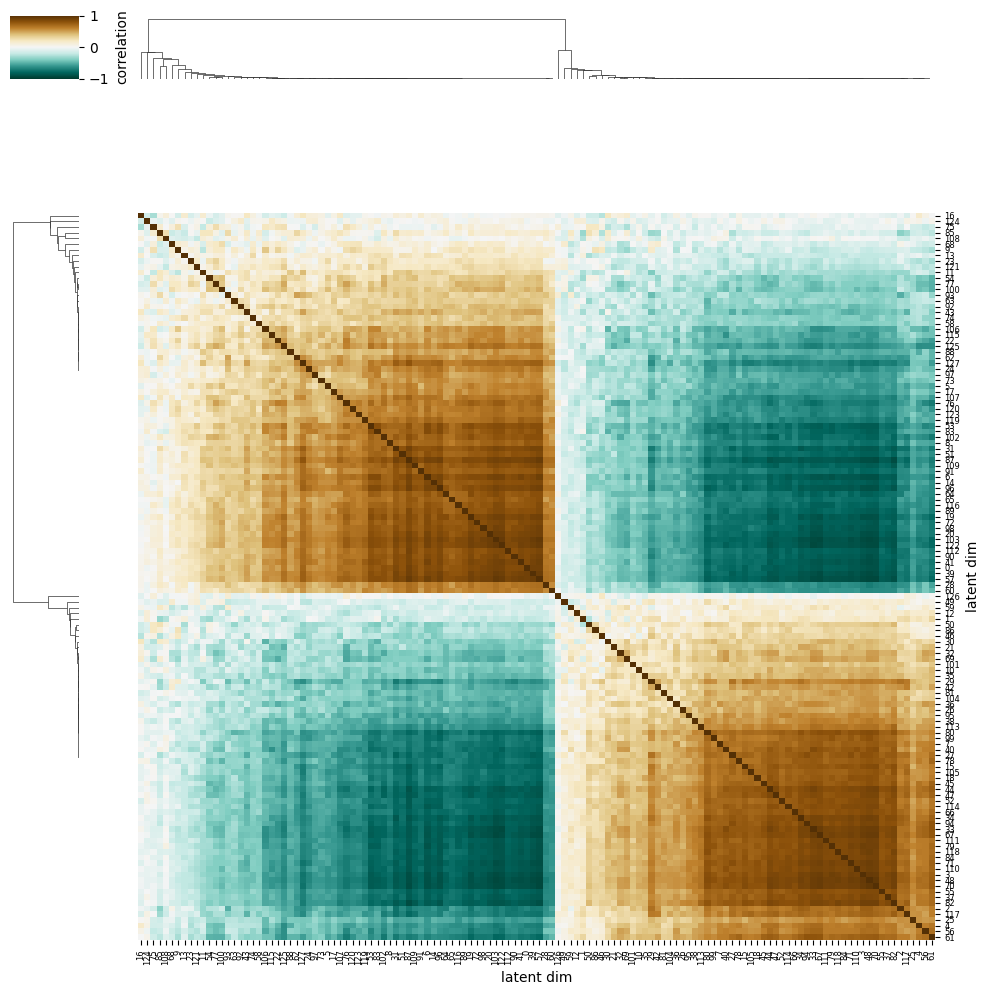

In [20]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result_s1, z_key="_local_emb", vmax=1.0, cmap="BrBG_r", label_fontsize=6)
pl_latent_correlation(result_s1, z_key="_global_emb", vmax=1.0, cmap="BrBG_r", label_fontsize=6)

In [21]:
# Check rank:
rep_global = latent_rank_report(result_s2, "_global_emb")
rep_local  = latent_rank_report(result_s2, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 126421, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 126421, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


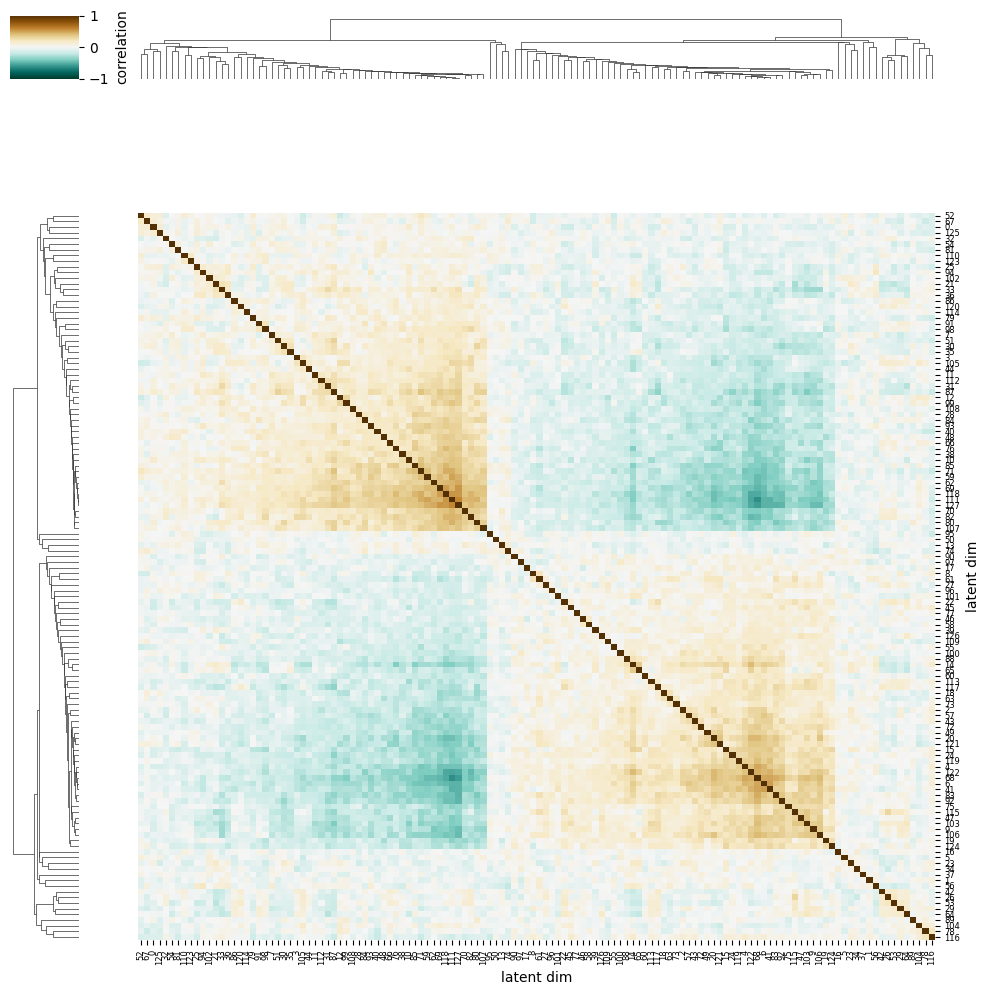

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


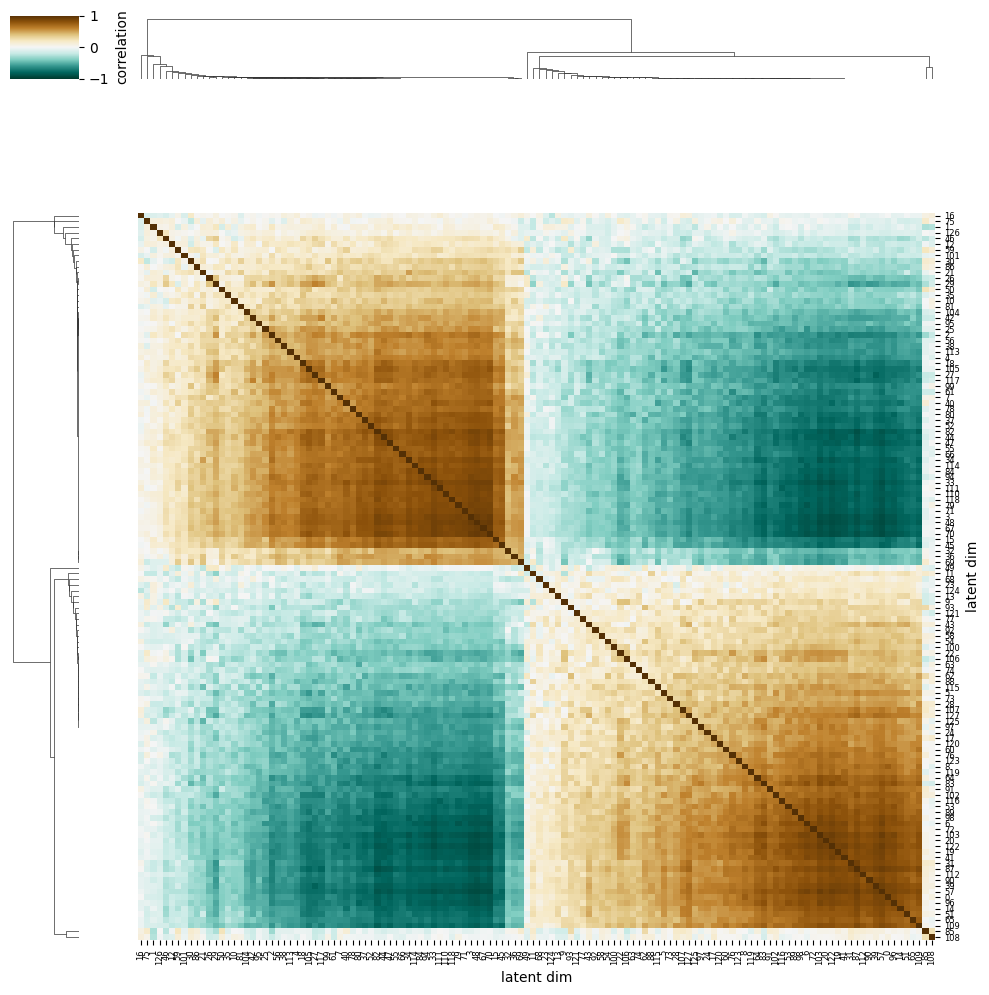

In [22]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result_s2, z_key="_local_emb", vmax=1.0, cmap="BrBG_r", label_fontsize=6)
pl_latent_correlation(result_s2, z_key="_global_emb", vmax=1.0, cmap="BrBG_r", label_fontsize=6)

In [23]:
# Check rank:
rep_global = latent_rank_report(result_s3, "_global_emb")
rep_local  = latent_rank_report(result_s3, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 151595, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 151595, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


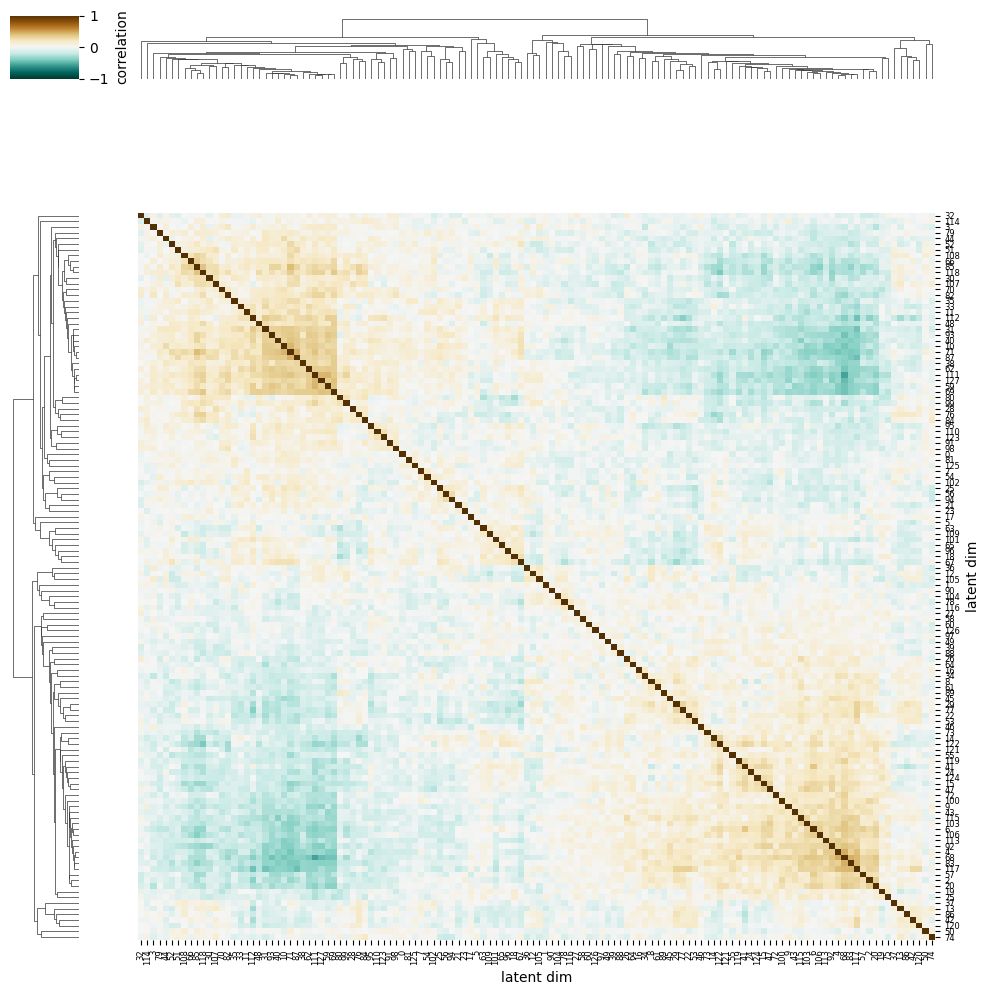

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


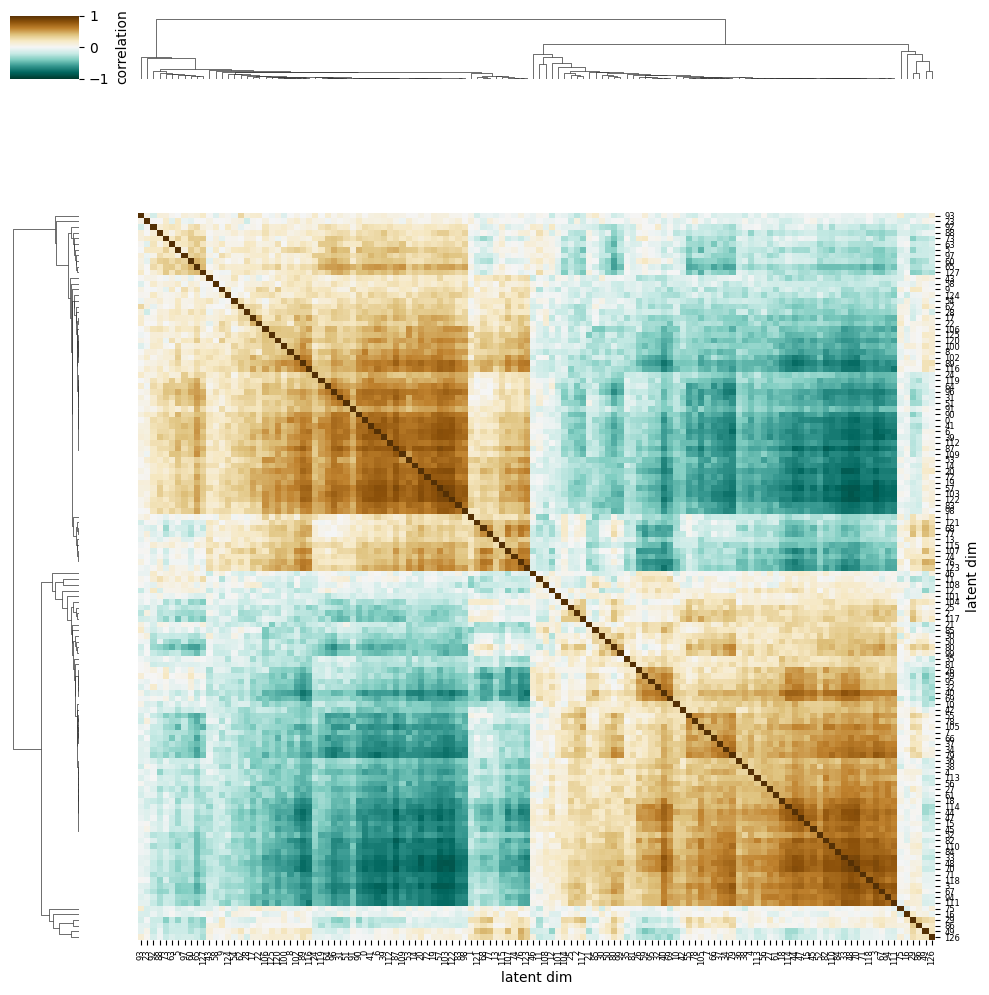

In [24]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result_s3, z_key="_local_emb", vmax=1.0, cmap="BrBG_r",label_fontsize=6)
pl_latent_correlation(result_s3, z_key="_global_emb", vmax=1.0, cmap="BrBG_r", label_fontsize=6)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(952.7777777777777, 0.5, 'local latent dim')

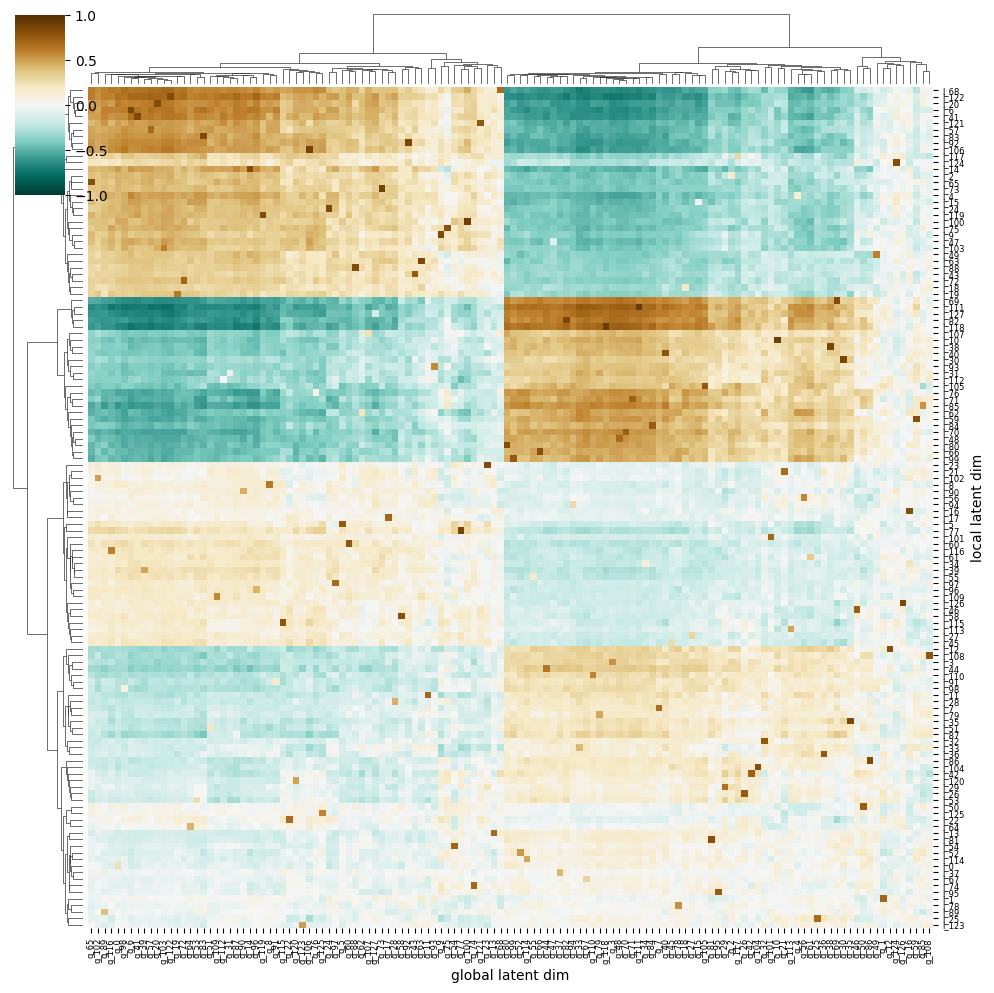

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Z_local = result_s1.obsm["_local_emb"]
Z_global = result_s1.obsm["_global_emb"]

# Standardize each dim across cells
Zl = (Z_local - Z_local.mean(axis=0)) / Z_local.std(axis=0, ddof=1)
Zg = (Z_global - Z_global.mean(axis=0)) / Z_global.std(axis=0, ddof=1)

# Cross-correlation: (L x N) @ (N x G) -> (L x G)
C = (Zl.T @ Zg) / (Zl.shape[0] - 1)

# Labels
row_labels = [f"l_{i}" for i in range(C.shape[0])]
col_labels = [f"g_{j}" for j in range(C.shape[1])]

g = sns.clustermap(
    C,
    dendrogram_ratio=(0.08, 0.08),
    cmap="BrBG_r",
    vmin=-1.0,
    vmax=1.0,
    figsize=(10, 10),
    method="average",
    metric="euclidean",
    xticklabels=col_labels,
    yticklabels=row_labels,
    z_score=None,
    standard_scale=None,
    #cbar_kws={"label": "corr"},
)

# Rotate and resize tick labels
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=6
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=6
)

g.ax_heatmap.set_xlabel("global latent dim")
g.ax_heatmap.set_ylabel("local latent dim")

##### 2. Per-dimension contribution to variance of reconstructed gene expression

Because we're using a linear decoder and we have uncorrelated embedding dimensions then: 

```Var(Ŷ) ~ tr((W^TW)Cov(H))```

In [26]:
from InterScale.evaluation import pl_dim_importance_elbow_stdexpr, get_genes_dim


20% cumulative variance reached with 10 dimensions:
Embedding dimensions (sorted by importance):
[48, 57, 96, 6, 3, 103, 70, 111, 118, 82]


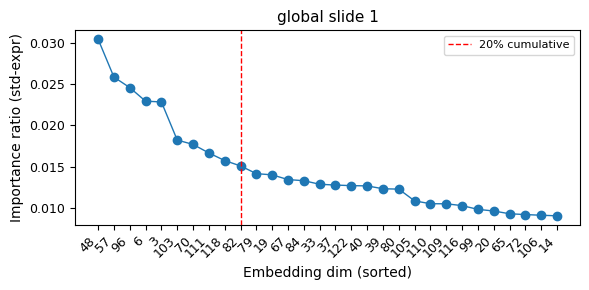


20% cumulative variance reached with 6 dimensions:
Embedding dimensions (sorted by importance):
[87, 57, 48, 103, 70, 3]


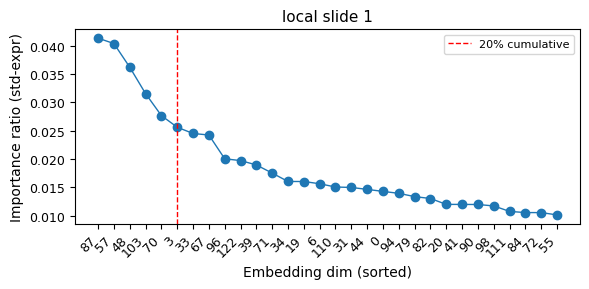

<Axes: title={'center': 'local slide 1'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

In [33]:
pl_dim_importance_elbow_stdexpr(
    result_s1,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="global slide 1",
    show=True,
)

pl_dim_importance_elbow_stdexpr(
    result_s1,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="local slide 1",
    show=True,
)


20% cumulative variance reached with 11 dimensions:
Embedding dimensions (sorted by importance):
[48, 70, 3, 96, 57, 6, 103, 111, 118, 33, 39]


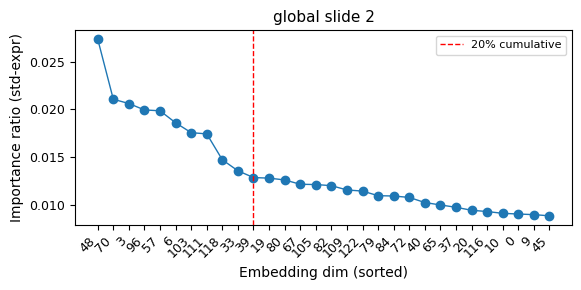


20% cumulative variance reached with 7 dimensions:
Embedding dimensions (sorted by importance):
[87, 57, 48, 103, 70, 3, 33]


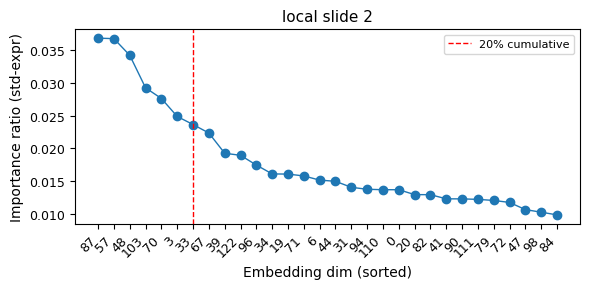

<Axes: title={'center': 'local slide 2'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

In [34]:
pl_dim_importance_elbow_stdexpr(
    result_s2,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="global slide 2",
    show=True,
)

pl_dim_importance_elbow_stdexpr(
    result_s2,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="local slide 2",
    show=True,
)


20% cumulative variance reached with 14 dimensions:
Embedding dimensions (sorted by importance):
[48, 70, 76, 40, 33, 68, 3, 96, 57, 111, 103, 6, 80, 59]


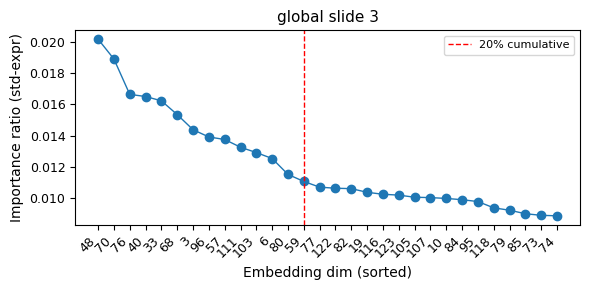


20% cumulative variance reached with 9 dimensions:
Embedding dimensions (sorted by importance):
[57, 48, 87, 70, 33, 103, 3, 44, 122]


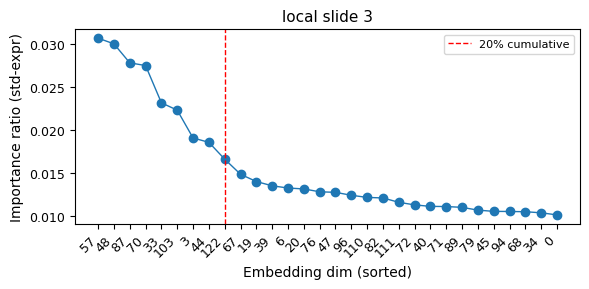

<Axes: title={'center': 'local slide 3'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

In [35]:
pl_dim_importance_elbow_stdexpr(
    result_s3,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="global slide 3",
    show=True,
)

pl_dim_importance_elbow_stdexpr(
    result_s3,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=30,
    figsize=(6, 3),
    fontsize=10,
    title="local slide 3",
    show=True,
)

##### 3. Gene scoring 

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.  

- Expression filtering:
| Argument   | Effect                               |
| ---------- | ------------------------------------ |
| `X_layer`  | Expression matrix used for filtering |
| `min_frac` | Remove rare genes                    |
| `min_sd`   | Remove low-variance genes            |

- Scoring choices
| Argument                 | Meaning                                |
| ------------------------ | -------------------------------------- |
| `rank_by="loading"`      | Pure decoder sensitivity               |
| `rank_by="loading_x_sd"` | Favor highly variable genes            |
| `residualize=True`       | Use only unique component of dimension |

- Specificity control
| Argument                   | Meaning                              |
| -------------------------- | ------------------------------------ |
| `enforce_specificity`      | Force genes to be dimension-specific |
| `specificity_mode="ratio"` | max/second criterion                 |
| `specificity_min`          | How strict the specificity must be   |

 
gene_by_dim_heatmap interpretation:

So:

Dark brown → strong positive association with that dimension

Dark green → strong negative association

Near white → little association

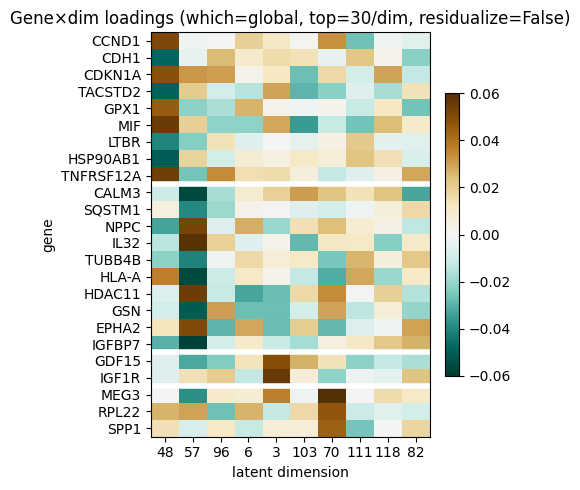

In [41]:
df_global, ax = get_genes_dim(
    result_s1,
    which="global",
    dims=[48, 57, 96, 6, 3, 103, 70, 111, 118, 82],
    n_top=30,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    #specificity_min=2.0,
    #residualize=True,
    plot=True,
    figsize=(5, 5),
)

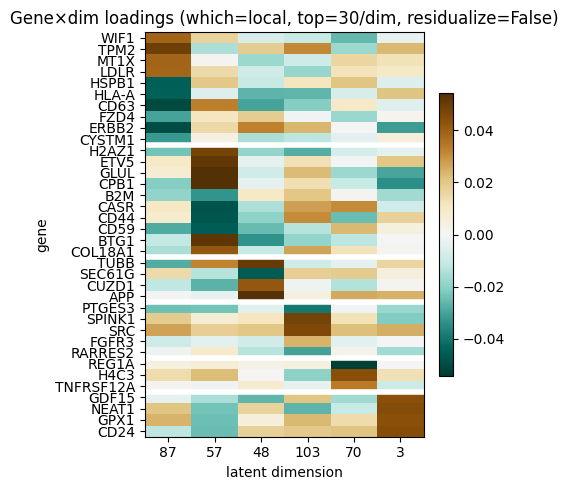

In [40]:
df_local, ax = get_genes_dim(
    result_s1,
    which="local",
    dims=[87, 57, 48, 103, 70, 3],
    n_top=30,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    #specificity_min=2.0,
    #residualize=True,
    plot=True,
    figsize=(5, 5),
)

In [39]:
global_genes = df_global.index 
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

Shared: ['GPX1', 'TNFRSF12A', 'HLA-A', 'GDF15']
Unique local: ['APP', 'B2M', 'BTG1', 'CASR', 'CD24', 'CD44', 'CD59', 'CD63', 'COL18A1', 'CPB1', 'CUZD1', 'CYSTM1', 'ERBB2', 'ETV5', 'FGFR3', 'FZD4', 'GLUL', 'H2AZ1', 'H4C3', 'HSPB1', 'LDLR', 'MT1X', 'NEAT1', 'PTGES3', 'RARRES2', 'REG1A', 'SEC61G', 'SPINK1', 'SRC', 'TPM2', 'TUBB', 'WIF1']
Unique global: ['CALM3', 'CCND1', 'CDH1', 'CDKN1A', 'EPHA2', 'GSN', 'HDAC11', 'HSP90AB1', 'IGF1R', 'IGFBP7', 'IL32', 'LTBR', 'MEG3', 'MIF', 'NPPC', 'RPL22', 'SPP1', 'SQSTM1', 'TACSTD2', 'TUBB4B']


In [67]:
import squidpy as sq

In [68]:
result.X.max()

4.8127866

In [ ]:
#96, 6, 111, 122, 40, 80
result.obs['z48_global'] = result.obsm['_global_emb'][:,48]

result.obs['z87_local'] = result.obsm['_local_emb'][:,87]

In [ ]:
result.obs['slide'].cat.categories

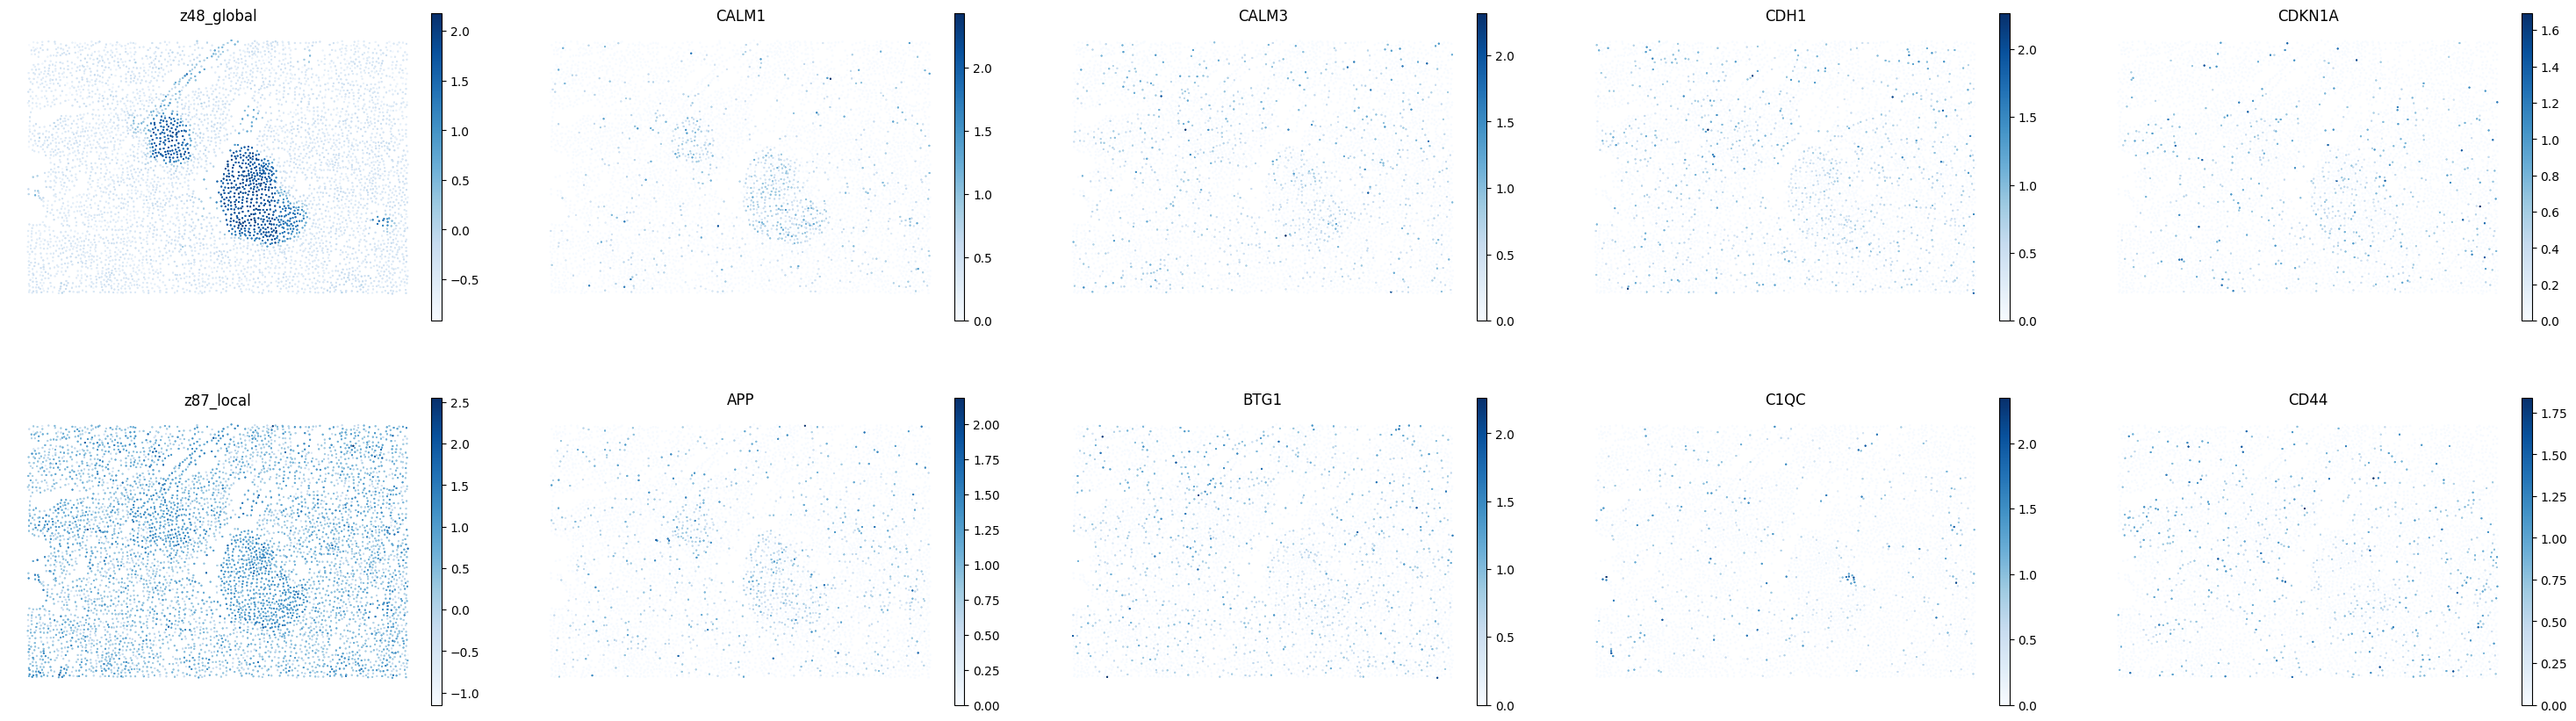

In [74]:
sq.pl.spatial_scatter(result[result.obs['slide'] == 'Run5211_S1'], 
                      library_key='fov',
                      library_id=['12'],
                      color = ['z48_global','CALM1', 'CALM3', 'CDH1', 'CDKN1A','z87_local','APP', 'BTG1', 'C1QC', 'CD44'],
                      cmap = 'Blues',
                      ncols=5,
                      shape= None, 
                      frameon=False
                     )

In [75]:
sc.tl.score_genes(result, gene_list=unique_local, score_name="local_score")
sc.tl.score_genes(result, gene_list=unique_global, score_name="global_score")

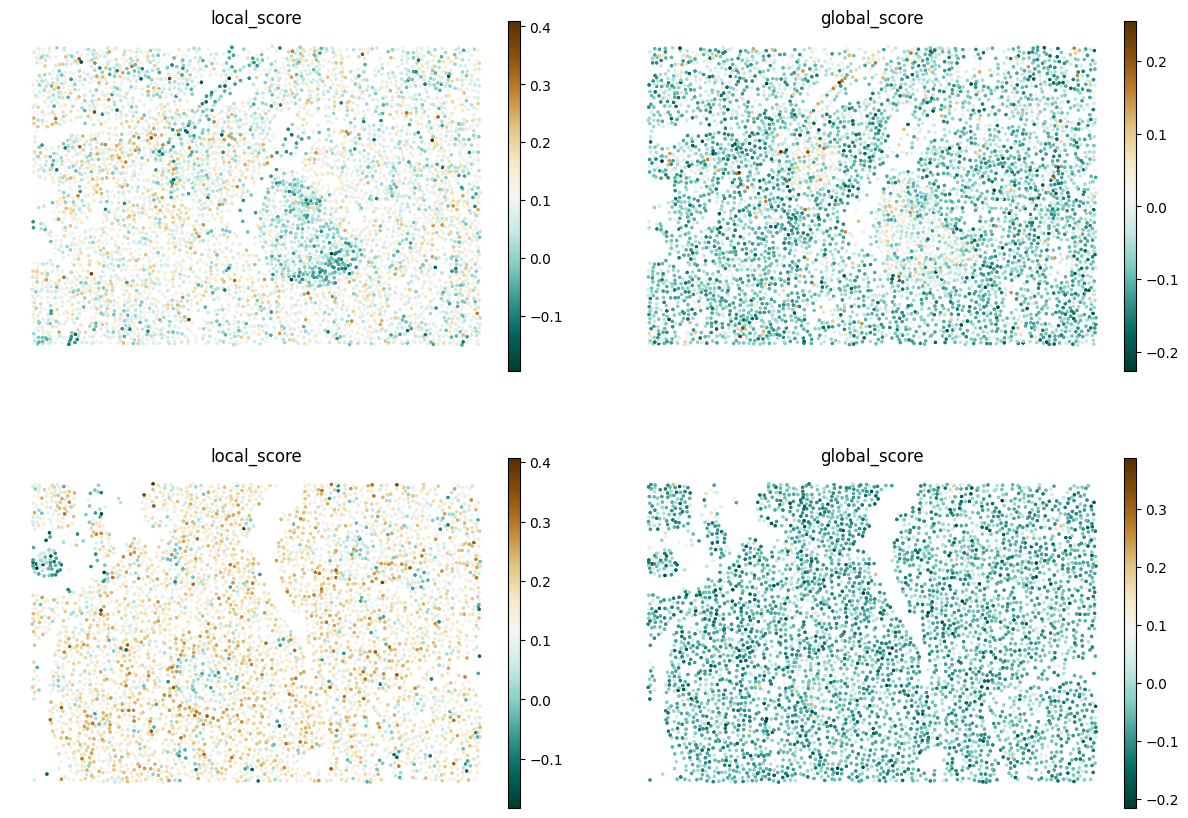

In [77]:
sq.pl.spatial_scatter(result[result.obs["slide"] == "Run5211_S1"], 
                      library_key="fov",
                      #library_id=["12","10"],
                      color = ["local_score","global_score"],
                      cmap = 'BrBG_r',
                      ncols=6,
                      shape= None, 
                      frameon=False,
                      size=8
                     )

In [78]:
import gseapy as gp

In [68]:
df_global['11']

AC129492.1   -0.119976
TBP          -0.165882
VAMP2        -0.165495
FOXO6        -0.012368
NEUROD1      -0.064061
NEUROG2      -0.007818
OLIG2         0.012347
PAX7         -0.001082
DBX1         -0.007140
HHIP         -0.035784
PER3          0.186289
POLR1B        0.006371
PROM1        -0.081192
ZNF609        0.000206
Name: 11, dtype: float64

In [79]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_global.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Substantia Nigra Development (GO:0021762),3/44,0.000022,0.002714,0,0,66.299335,710.760568,NPPC;CALM3;CALM1
1,GO_Biological_Process_2025,Regulation of High Voltage-Gated Calcium Chann...,2/6,0.000022,0.002714,0,0,434.152174,4647.628510,CALM3;CALM1
2,GO_Biological_Process_2025,Positive Regulation of Ryanodine-Sensitive Cal...,2/7,0.000031,0.002714,0,0,347.304348,3601.323532,CALM3;CALM1
3,GO_Biological_Process_2025,Negative Regulation of Voltage-Gated Calcium C...,2/7,0.000031,0.002714,0,0,347.304348,3601.323532,CALM3;CALM1
4,GO_Biological_Process_2025,Regulation of Heart Contraction (GO:0008016),3/70,0.000089,0.005665,0,0,40.518318,377.746566,TPM1;CALM3;CALM1


In [80]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_local.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Antimicrobial Humoral Response (GO:0019730),4/147,0.000037,0.009257,0,0,25.214240,257.351888,APP;RARRES2;REG1A;CXCL2
1,GO_Biological_Process_2025,Regulation of Protein Localization to Nucleus ...,3/56,0.000052,0.009257,0,0,49.026251,483.945093,APP;GLUL;INS
2,GO_Biological_Process_2025,+ Reg of Phosphatidylinositol 3-Kinase/Prot Ki...,4/162,0.000054,0.009257,0,0,22.803222,224.094775,APP;SRC;SPRY2;INS
3,GO_Biological_Process_2025,Regulation of Dendritic Spine Maintenance (GO:...,2/9,0.000058,0.009257,0,0,237.702381,2318.092903,APP;INS
4,GO_Biological_Process_2025,Regulation of Lamellipodium Morphogenesis (GO:...,2/10,0.000073,0.009257,0,0,207.979167,1981.986469,SRC;CD44


In [81]:
df_local = enr_local.results
df_global = enr_global.results

In [82]:
top_local = df_local.sort_values("Adjusted P-value").head(10)
top_global = df_global.sort_values("Adjusted P-value").head(10)

In [83]:
df_local["group"] = "Local"
df_global["group"] = "Global"

combined = pd.concat([
    df_local.sort_values("Adjusted P-value").head(10),
    df_global.sort_values("Adjusted P-value").head(10)
])

combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"])

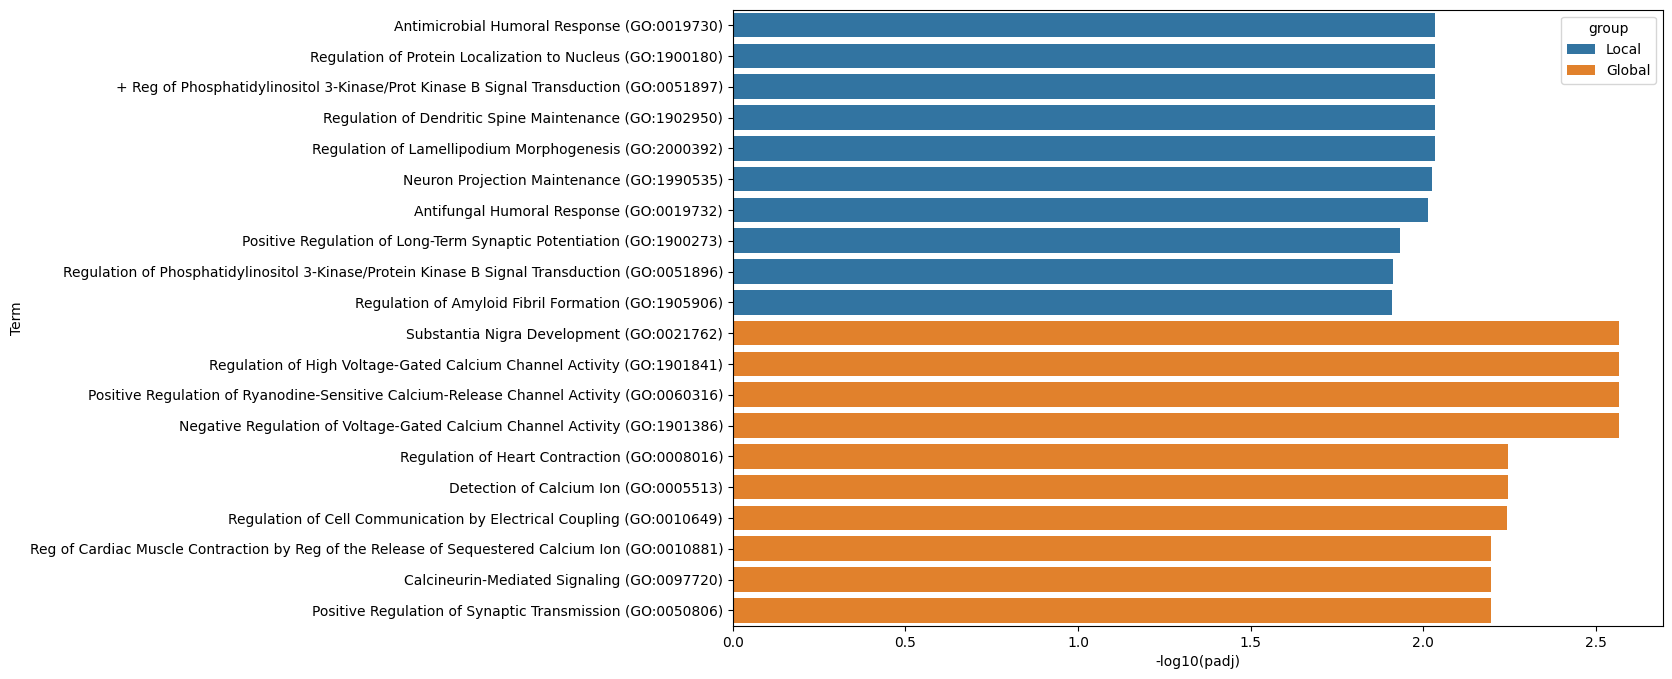

In [84]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.barplot(
    data=combined,
    y="Term",
    x="-log10(padj)",
    hue="group"
)
plt.show()

### Gene rank analysis

In [47]:
ctrl_test.layers['_y_pred_local']

array([[-0.41784543,  0.10436597,  0.15581939, ..., -0.439008  ,
        -0.8869709 , -0.24236163],
       [-0.18968302, -0.21860307, -0.188813  , ..., -0.93693584,
        -0.8444304 , -0.01079343],
       [-0.2361882 ,  0.70588744,  0.231318  , ...,  0.16956502,
        -1.0536482 ,  0.4068437 ],
       ...,
       [-0.27271843, -0.07589218, -0.2681569 , ..., -0.6622197 ,
        -0.46413535, -0.08217128],
       [-0.40162152,  0.41832587, -0.07500255, ..., -0.27980423,
        -1.0338154 , -0.17561972],
       [-0.456762  ,  0.09235121, -0.21919376, ..., -0.6240566 ,
        -0.7109809 , -0.25395873]], dtype=float32)

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


Top 5 genes for _y_pred_local model:
       gene        r2    r2_log  r2_rank
61   OLIG2  0.098329  0.093790     88.0
11    CHAT  0.050963  0.049707     87.0
47    MNX1  0.010942  0.010883     86.0
26   FOXA2  0.009009  0.008969     85.0
53  NKX2.1  0.000000  0.000000     82.5
Top 5 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
25   FOXA1  0.015374  0.015257     88.0
62     OTP  0.007413  0.007385     87.0
53  NKX2.1  0.000000  0.000000     84.5
74    SIX6  0.000000  0.000000     84.5
86   FOXG1  0.000000  0.000000     84.5


/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


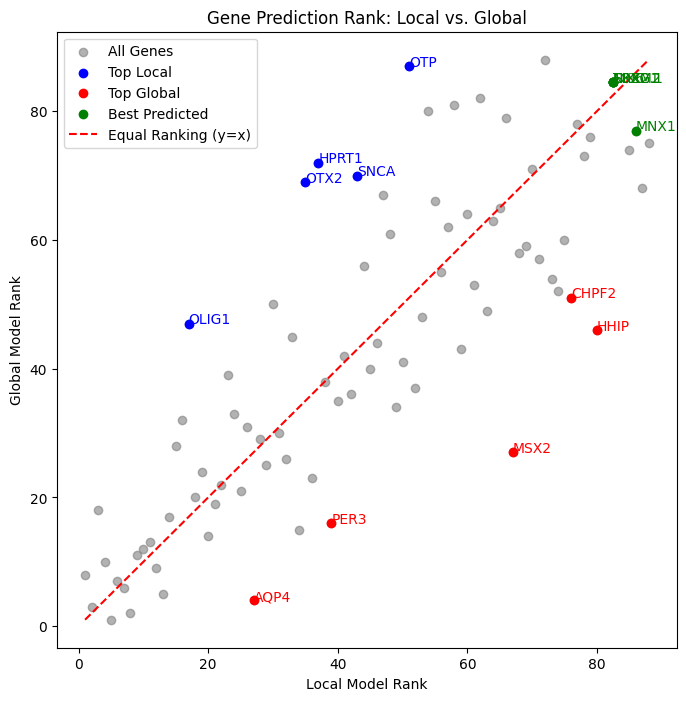

(     gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 62    OTP        51.0         87.0            -36.0      69.0
 38  HPRT1        37.0         72.0            -35.0      54.5
 63   OTX2        35.0         69.0            -34.0      52.0
 60  OLIG1        17.0         47.0            -30.0      32.0
 76   SNCA        43.0         70.0            -27.0      56.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 49   MSX2        67.0         27.0             40.0      47.0
 36   HHIP        80.0         46.0             34.0      63.0
 12  CHPF2        76.0         51.0             25.0      63.5
 4    AQP4        27.0          4.0             23.0      15.5
 67   PER3        39.0         16.0             23.0      27.5,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 53  NKX2.1        82.5         84.5             -2.0      83.5
 74    SIX6        82.5         84.5             -2.0      83.5
 86   FOXG1        82.5         84.5             -

In [48]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(ctrl_test,#result[result.obs['condition'] =='Ctrl'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)

### Cluster by distance 

In [31]:
gene_name = 'SHH'
threshold = 3.5 # can depend on the slide? 

if gene_name in result.var_names:
    gene_expression = result[:, gene_name].X
    if not isinstance(gene_expression, np.ndarray):
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    else:
        gene_expression = gene_expression.flatten()

    # Annotate cells in the obs field based on the expression threshold
    result.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
else:
    print(f"Gene '{gene_name}' not found in adata.var_names.")

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


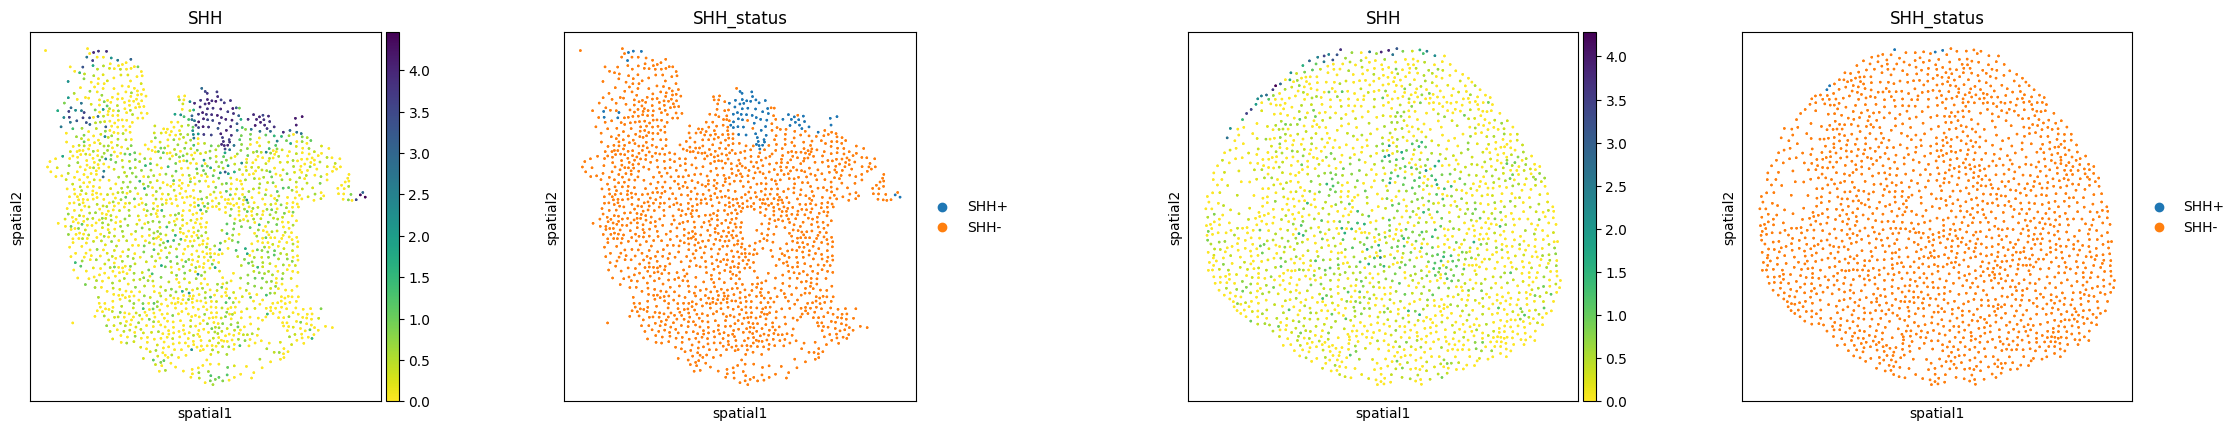

In [32]:
sq.pl.spatial_scatter(result, 
                      library_key='sample',
                      library_id=['slide4_B2-2','slide4_A2-3'],
                      color = ['SHH','SHH_status'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [48]:
# Coordinates
coords = result.obsm["spatial"]
shh_coords = coords[result.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
result.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(result, use_rep=None, n_neighbors=10)
result.obs["distance_cluster"] = np.digitize(result.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [ ]:
# Coordinates
coords = ctrl_test.obsm["spatial"]
shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
ctrl_test.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

In [49]:
dist = result.obs["dist_to_SHH+"].to_numpy()

n_bins = 5
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

result.obs["SHH_dist_ring"] = cats

In [ ]:
dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

n_bins = 5
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

ctrl_test.obs["SHH_dist_ring"] = cats

In [51]:
result.uns['SHH_dist_ring_colors'] = ['#556FA7','#C62A22','#7A81FF','#679B36','#E38236']

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


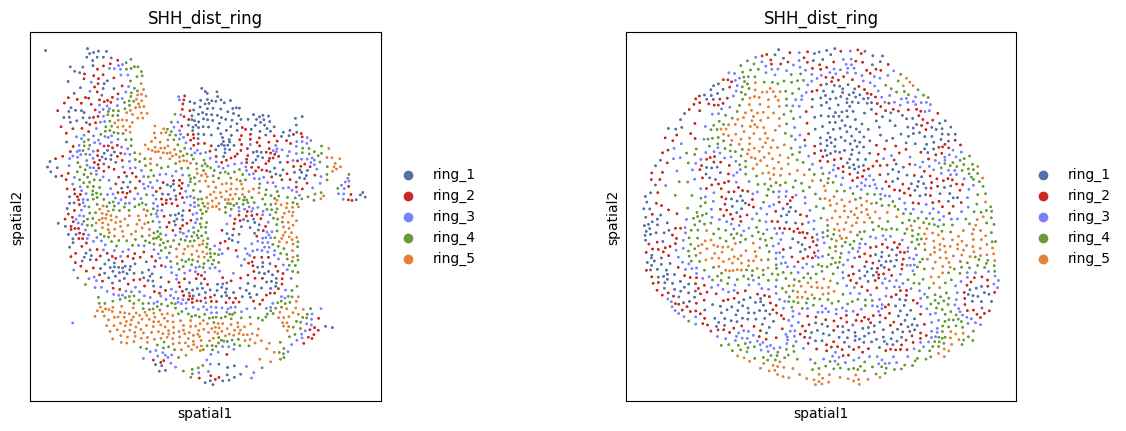

In [52]:
sq.pl.spatial_scatter(result, 
                      library_key='sample',
                      library_id=['slide4_B2-2','slide4_A2-3'],
                      color = ['SHH_dist_ring'],
                      #cmap = 'viridis_r',
                      shape= None
                     )

In [ ]:
sc.pl.dotplot(ctrl_test, var_names=unique_global, groupby='SHH_dist_ring', standard_scale='var', cmap='BrBG_r')

In [ ]:
sc.pl.dotplot(ctrl_test, var_names=unique_local, groupby='SHH_dist_ring', standard_scale='var', cmap='BrBG_r')

In [ ]:
rings = ctrl_test.obs["SHH_dist_ring"].astype("category")
emb = ctrl_test.obsm["_local_emb"]  # shape: (n_cells, d)
d = emb.shape[1]

# --- make a DataFrame for easy grouping
#cols = [f"dim_{i+1}" for i in range(d)]
cols = [f"dim_{i}" for i in range(d)]
df = pd.DataFrame(emb, columns=cols)
df["ring"] = rings.values

# ensure ordered rows by categorical order
ordered_rings = list(rings.cat.categories)

# --- aggregate: mean per ring (you can swap to .median() if you prefer)
M = (df.groupby("ring")[cols]
       .mean()
       .reindex(ordered_rings))

# --- optional: z-score each column so colors are comparable across dims
# comment this block if you prefer raw means
M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
M = M.fillna(0.0)

# --- plot with matplotlib
fig_h = 0.6 * len(ordered_rings) + 2
fig_w = min(0.45 * d + 3, 18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M.values, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Embedding (z-score)")

# ticks/labels
ax.set_yticks(range(len(ordered_rings)))
ax.set_yticklabels(ordered_rings)

# For many dims, thin x tick labels
step = 1 if d <= 30 else (2 if d <= 60 else 5)
ax.set_xticks(range(0, d, step))
ax.set_xticklabels([cols[i] for i in range(0, d, step)], rotation=90)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Distance-based cluster (rings)")
ax.set_title("Local embedding by SHH distance rings")

plt.tight_layout()
plt.show()

In [33]:
result.obs['condition'].cat.categories

Index(['Ctrl', 'SHH'], dtype='object')

In [34]:
sq.tl.var_by_distance(
    adata=result,
    groups="SHH+",
    cluster_key="SHH_status",
    library_key="sample",
    #library_id='slide4_B2-2'
    covariates=["condition"],
)

In [38]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical', 'z11_global', 'z5_global', 'z1_global', 'z7_global', 'z10_global', 'z13_local', 'z1_local', 'z14_local', 'z7_local', 'z0_local', 'z2_local', 'SHH_status'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'SHH_status_colors', 'condition_colors'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix', 'design_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

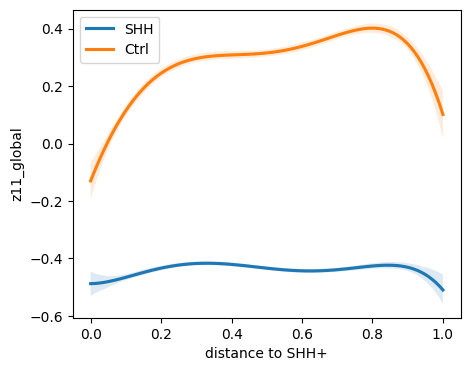

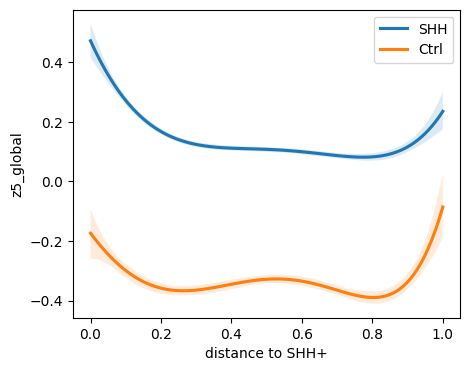

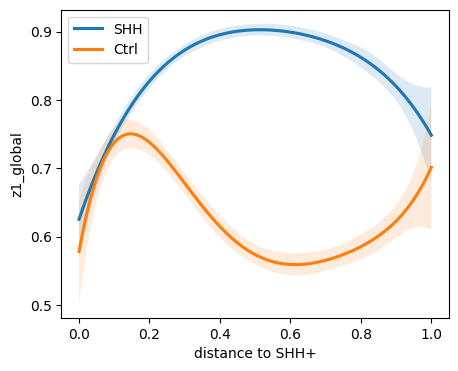

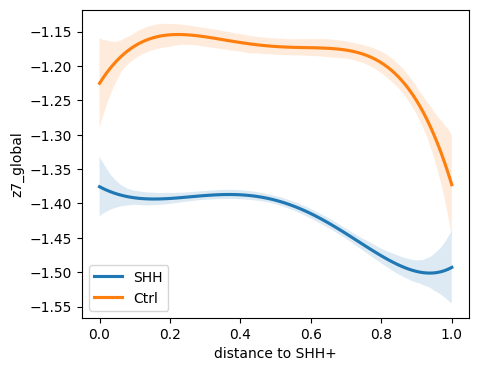

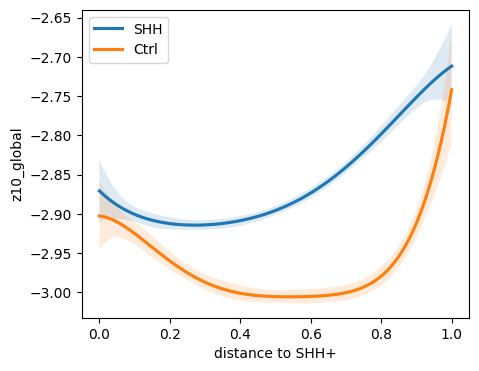

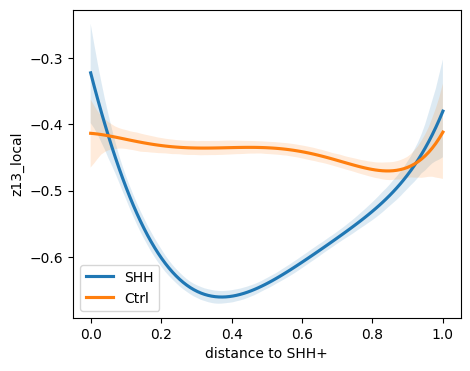

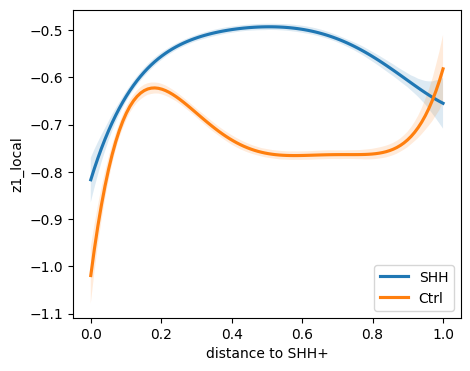

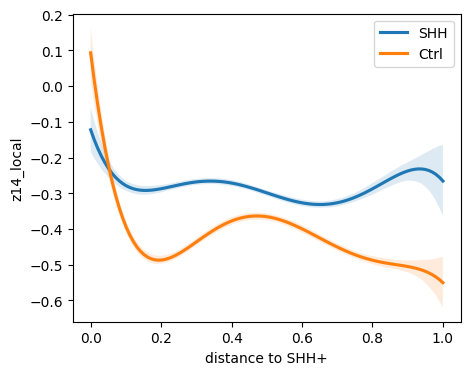

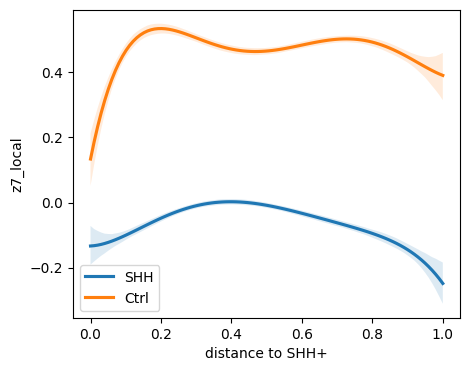

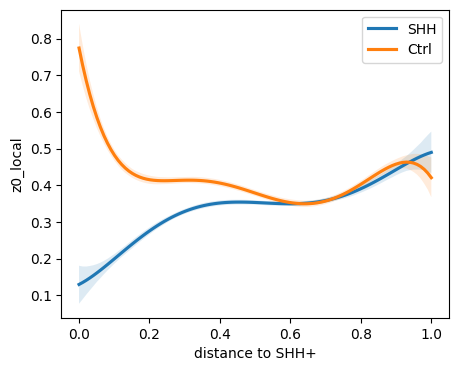

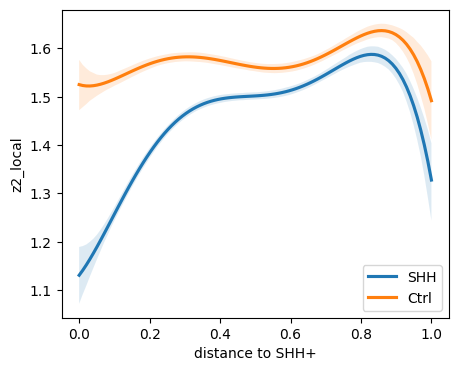

In [39]:
to_plot = ['z11_global', 'z5_global', 'z1_global', 'z7_global', 'z10_global', 'z13_local', 'z1_local', 'z14_local', 'z7_local', 'z0_local', 'z2_local']

for var2plot in to_plot:
    sq.pl.var_by_distance(
        adata=result,
        design_matrix_key="design_matrix",
        var=var2plot,
        #stack_vars=True,
        anchor_key="SHH+",
        covariate="condition",
        #line_palette=["blue", "orange"],
        show_scatter=False,
        figsize=(5, 4),
    )